In [1]:
# importing everything needed for ml
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# loading cleaned data
df = pd.read_csv('salesforce_pro_cleaned.csv')
df['order_date'] = pd.to_datetime(df['order_date'])

print(df.shape)


(49728, 27)


In [2]:
# finding each customer's last order date
last_order = df.groupby('customer_id')['order_date'].max().reset_index()
last_order.columns = ['customer_id', 'last_order_date']

# reference date — last date in our dataset
reference_date = df['order_date'].max()

# if a customer hasn't ordered in 180 days — they are churned
last_order['days_since_last_order'] = (reference_date - last_order['last_order_date']).dt.days
last_order['churn'] = (last_order['days_since_last_order'] > 180).astype(int)

print(last_order['churn'].value_counts())
print()
print(f"churn rate: {last_order['churn'].mean() * 100:.1f}%")

churn
0    5884
1    2100
Name: count, dtype: int64

churn rate: 26.3%


In [3]:
# for each customer i want to know how they behaved so i am grouping by customer and calculating some basic stats

total_orders = df.groupby('customer_id')['order_id'].count()
total_revenue = df.groupby('customer_id')['sales_amount'].sum()
total_profit = df.groupby('customer_id')['profit'].sum()
avg_discount = df.groupby('customer_id')['discount'].mean()
avg_rating = df.groupby('customer_id')['customer_rating'].mean()
total_returns = df.groupby('customer_id')['return_flag'].sum()

# combining everything into one dataframe
customer_features = pd.DataFrame({
    'customer_id'   : total_orders.index,
    'total_orders'  : total_orders.values,
    'total_revenue' : total_revenue.values,
    'total_profit'  : total_profit.values,
    'avg_discount'  : avg_discount.values,
    'avg_rating'    : avg_rating.values,
    'total_returns' : total_returns.values
})

# adding the churn column
customer_features = customer_features.merge(last_order[['customer_id', 'days_since_last_order', 'churn']], 
                                            on='customer_id')

print(customer_features.shape)
print(customer_features.head())

(7984, 9)
  customer_id  total_orders  total_revenue  total_profit  avg_discount  \
0   CUST00001             5     2438994.48     535770.29      0.130000   
1   CUST00002            11     1554439.44     522324.83      0.100000   
2   CUST00003             7      261178.46      91470.11      0.100000   
3   CUST00004             7     1183725.93     525200.07      0.071429   
4   CUST00005             5      711927.71     183519.19      0.120000   

   avg_rating  total_returns  days_since_last_order  churn  
0    3.400000              0                     36      0  
1    3.727273              1                    103      0  
2    4.000000              1                     46      0  
3    3.714286              1                    119      0  
4    4.600000              1                     63      0  


In [7]:
X = customer_features.drop(['customer_id', 'churn', 'days_since_last_order'], axis=1)
y = customer_features['churn']

# splitting again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# retraining
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# checking performance
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.77      0.95      0.85      1197
           1       0.52      0.17      0.25       400

    accuracy                           0.75      1597
   macro avg       0.65      0.56      0.55      1597
weighted avg       0.71      0.75      0.70      1597



In [8]:
# the model is struggling with churned customers because we have less of them , using class_weight='balanced' tells the model to pay more attention to churned customers

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.94      0.85      1197
           1       0.49      0.17      0.25       400

    accuracy                           0.75      1597
   macro avg       0.63      0.56      0.55      1597
weighted avg       0.70      0.75      0.70      1597



In [9]:
# days_since_last_order directly defines churn so i need to remove it
# keeping it would mean the model is cheating — called data leakage

X = customer_features.drop(['customer_id', 'churn', 'days_since_last_order'], axis=1)
y = customer_features['churn']

# splitting again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# retraining
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# checking performance
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.95      0.85      1197
           1       0.52      0.17      0.25       400

    accuracy                           0.75      1597
   macro avg       0.65      0.56      0.55      1597
weighted avg       0.71      0.75      0.70      1597



In [10]:
# adding a new feature revenue per order , customers who spend more per order might behave differently
customer_features['revenue_per_order'] = customer_features['total_revenue'] / customer_features['total_orders']
customer_features['return_rate'] = customer_features['total_returns'] / customer_features['total_orders']

# redefining features with new columns
X = customer_features.drop(['customer_id', 'churn', 'days_since_last_order'], axis=1)
y = customer_features['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.94      0.84      1197
           1       0.45      0.15      0.23       400

    accuracy                           0.74      1597
   macro avg       0.61      0.54      0.53      1597
weighted avg       0.69      0.74      0.69      1597



total_profit         0.201301
total_revenue        0.191979
revenue_per_order    0.190285
avg_discount         0.145457
avg_rating           0.122627
total_orders         0.098828
return_rate          0.031304
total_returns        0.018219
dtype: float64


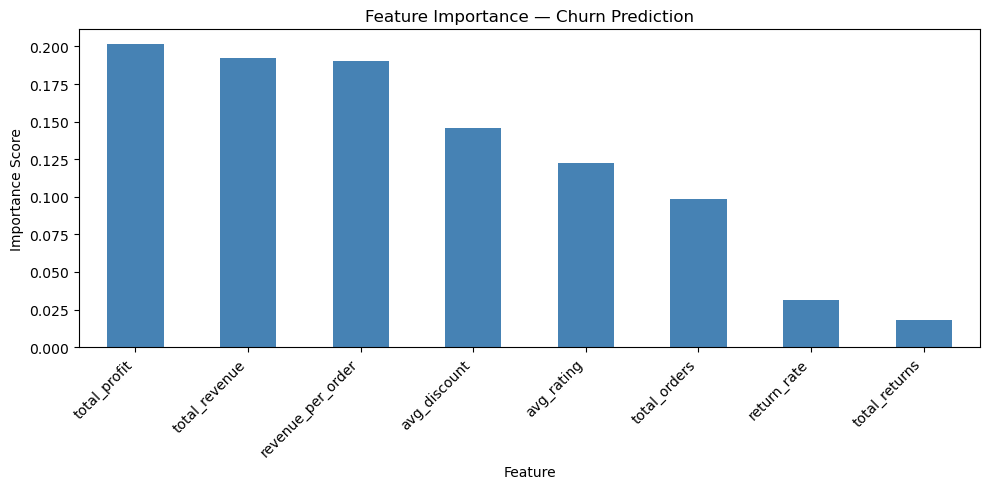

In [11]:
# which features does the model think are most important for predicting churn
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

# plotting
feature_importance.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Feature Importance — Churn Prediction')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Churn Prediction Model - Random Forest

Built a churn model to identify customers who haven't ordered in 180+ days using features like total revenue, order count, discount and return rate. Faced and resolved a data leakage issue by removing days_since_last_order, bringing accuracy to a realistic 74%.
Spending behaviour (total profit, revenue per order) is the strongest predictor of churn accounting for 58% of the model's decision making.

In [13]:
# grouping revenue by month to create a time series
monthly_revenue = df.groupby(['order_year', 'order_month'])['sales_amount'].sum().reset_index()

# creating a proper date column
monthly_revenue['date'] = pd.to_datetime({
    'year'  : monthly_revenue['order_year'],
    'month' : monthly_revenue['order_month'],
    'day'   : 1
})

monthly_revenue = monthly_revenue.sort_values('date').reset_index(drop=True)

print(monthly_revenue.head(10))
print(f'total months: {len(monthly_revenue)}')

   order_year  order_month  sales_amount       date
0        2021            1  1.041442e+08 2021-01-01
1        2021            2  1.130325e+08 2021-02-01
2        2021            3  1.323321e+08 2021-03-01
3        2021            4  1.266175e+08 2021-04-01
4        2021            5  1.410321e+08 2021-05-01
5        2021            6  1.277154e+08 2021-06-01
6        2021            7  1.386990e+08 2021-07-01
7        2021            8  1.562778e+08 2021-08-01
8        2021            9  1.539715e+08 2021-09-01
9        2021           10  1.645116e+08 2021-10-01
total months: 48


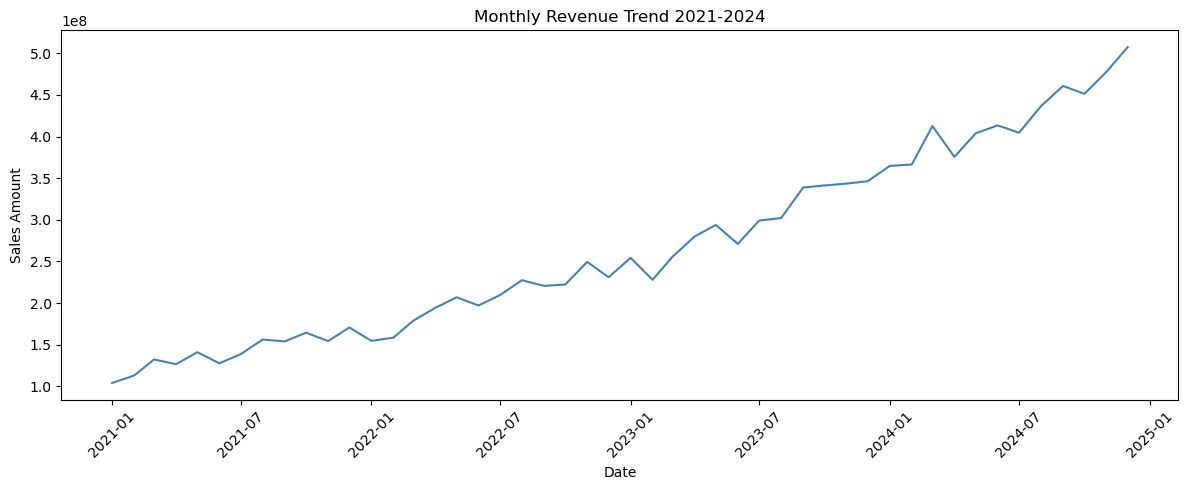

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['date'], monthly_revenue['sales_amount'], 
         color='steelblue', linewidth=1.5)
plt.title('Monthly Revenue Trend 2021-2024')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np

monthly_revenue['month_index'] = range(len(monthly_revenue))

# features and target
X = monthly_revenue[['month_index']]
y = monthly_revenue['sales_amount']
model_forecast = LinearRegression()
model_forecast.fit(X, y)

print(f'monthly revenue growth rate: ₹{model_forecast.coef_[0]:,.0f} per month')

monthly revenue growth rate: ₹7,890,518 per month


In [16]:
# predicting next 6 months — jan 2025 to june 2025
future_months = pd.DataFrame({
    'month_index': range(48, 54)
})

future_predictions = model_forecast.predict(future_months)
future_dates = pd.date_range(start='2025-01-01', periods=6, freq='MS')

forecast_df = pd.DataFrame({
    'date'          : future_dates,
    'predicted_revenue' : future_predictions.round(2)
})

print(forecast_df)

        date  predicted_revenue
0 2025-01-01       4.592251e+08
1 2025-02-01       4.671156e+08
2 2025-03-01       4.750061e+08
3 2025-04-01       4.828966e+08
4 2025-05-01       4.907872e+08
5 2025-06-01       4.986777e+08


In [17]:
# converting to crores for readability
forecast_df['predicted_revenue_cr'] = (forecast_df['predicted_revenue'] / 10000000).round(2)
print(forecast_df[['date', 'predicted_revenue_cr']])

        date  predicted_revenue_cr
0 2025-01-01                 45.92
1 2025-02-01                 46.71
2 2025-03-01                 47.50
3 2025-04-01                 48.29
4 2025-05-01                 49.08
5 2025-06-01                 49.87


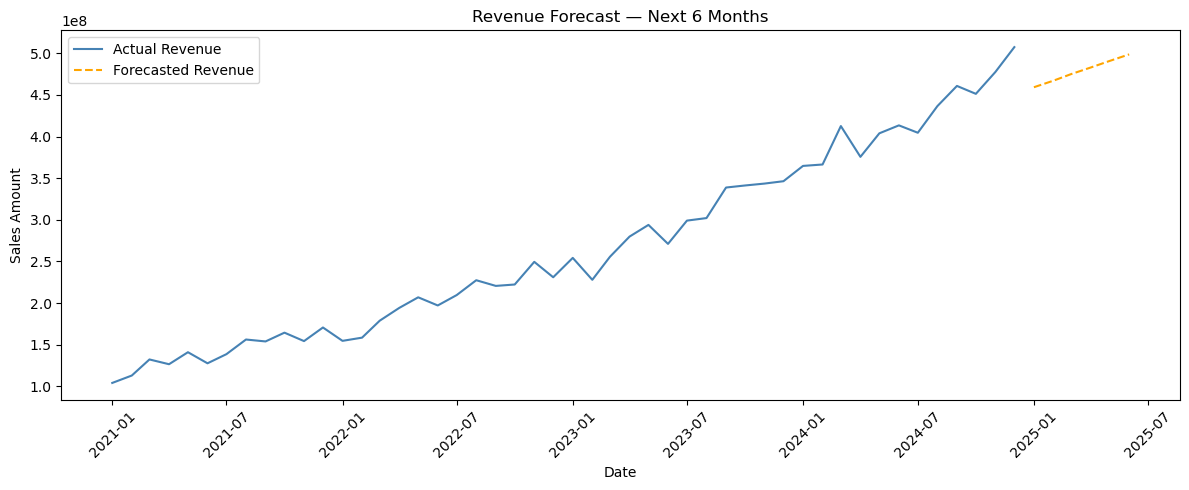

In [18]:
# plotting actual revenue vs forecasted revenue together
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['date'], monthly_revenue['sales_amount'], 
         color='steelblue', linewidth=1.5, label='Actual Revenue')
plt.plot(forecast_df['date'], forecast_df['predicted_revenue'], 
         color='orange', linewidth=1.5, linestyle='--', label='Forecasted Revenue')

plt.title('Revenue Forecast — Next 6 Months')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Sales Forecasting Model - Linear Regression

Built a Linear Regression model on 48 months of data to forecast next 6 months, with revenue growing at ₹78.9 Lakhs per month on average.
Revenue predicted between ₹45.9 Cr to ₹49.9 Cr per month for Jan–Jun 2025, continuing the upward trend seen since 2021.

In [19]:
X_test_copy = X_test.copy()
X_test_copy['actual_churn'] = y_test.values
X_test_copy['predicted_churn'] = y_pred

X_test_copy.to_csv('churn_predictions.csv', index=False)

# saving forecast to csv for power bi
forecast_df.to_csv('sales_forecast.csv', index=False)

print('files saved!')

files saved!
